🎯 Model loaded successfully! Computing performance metrics...

  FINAL RANDOM FOREST EVALUATION METRICS 
Mean Absolute Error (MAE)      : ₹13.44 Lakhs
Mean Squared Error (MSE)       : 967.67 (Lakhs²)
Root Mean Squared Error (RMSE) : ₹31.11 Lakhs
R² Score (Variance Explained)  : 0.8956 (89.56%)



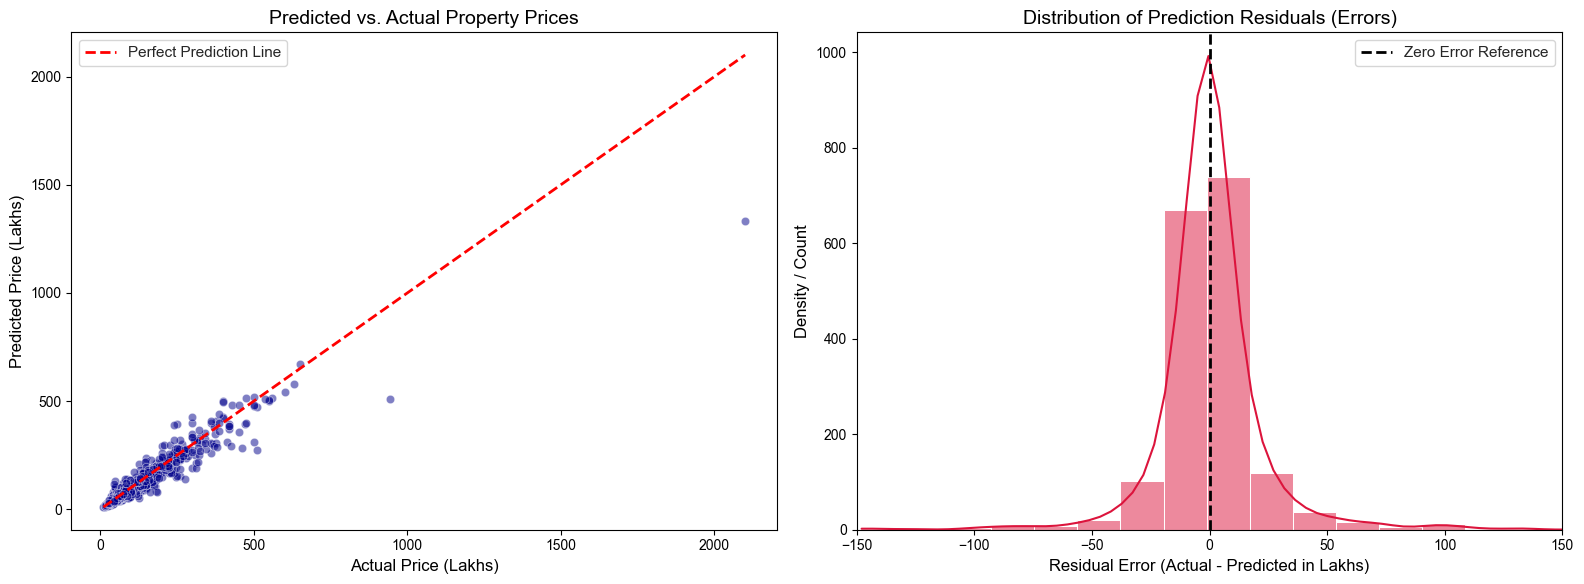

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the engineered data and recreate the exact same test split
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv')
X = df.drop(columns=['price'])
y = df['price']

# Make sure the random_state matches your training split (42)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Load your serialized winning Random Forest model from disk
model_path = r'C:\Users\varsh\Downloads\Real estate prediction model\models\bengaluru_rf_model.pkl'
try:
    loaded_rf_model = joblib.load(model_path)
    # Generate the missing predictions variable
    y_pred_rf = loaded_rf_model.predict(X_test)
    print("Model loaded successfully! Computing performance metrics...\n")
except FileNotFoundError:
    print(f"Error: Could not find your saved model at {model_path}.")
    print("Please make sure you ran the joblib.dump cell in your previous notebook first!")

# =====================================================================
# 3. Compute and plot all four core regression metrics (Now fully defined)
# =====================================================================
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("=========================================")
print("  FINAL RANDOM FOREST EVALUATION METRICS ")
print("=========================================")
print(f"Mean Absolute Error (MAE)      : ₹{mae:.2f} Lakhs")
print(f"Mean Squared Error (MSE)       : {mse:.2f} (Lakhs²)")
print(f"Root Mean Squared Error (RMSE) : ₹{rmse:.2f} Lakhs")
print(f"R² Score (Variance Explained)  : {r2:.4f} ({r2*100:.2f}%)")
print("=========================================\n")

# Set up side-by-side diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot A: Predicted vs. Actual Values
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred_rf, alpha=0.5, color='darkblue')
ideal_line = [y_test.min(), y_test.max()]
axes[0].plot(ideal_line, ideal_line, color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
axes[0].set_title('Predicted vs. Actual Property Prices', fontsize=14)
axes[0].set_xlabel('Actual Price (Lakhs)', fontsize=12)
axes[0].set_ylabel('Predicted Price (Lakhs)', fontsize=12)
axes[0].legend()

# Plot B: Residuals (Error) Distribution
residuals = y_test - y_pred_rf
sns.histplot(ax=axes[1], x=residuals, kde=True, color='crimson', bins=50)
axes[1].axvline(x=0, color='black', linestyle='--', lw=2, label='Zero Error Reference')
axes[1].set_title('Distribution of Prediction Residuals (Errors)', fontsize=14)
axes[1].set_xlabel('Residual Error (Actual - Predicted in Lakhs)', fontsize=12)
axes[1].set_ylabel('Density / Count', fontsize=12)
axes[1].set_xlim(-150, 150)
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
!pip install shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Import interpretation packages
import shap
from sklearn.inspection import PartialDependenceDisplay

# 1. Recreate split and load model
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv')
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = joblib.load(r'C:\Users\varsh\Downloads\Real estate prediction model\models\bengaluru_rf_model.pkl')

print("Context reloaded. Proceeding to deep model interpretation...\n")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   -- ------------------------------------- 2.9/39.2 MB 17.9 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/39.2 MB 19.5 MB/s eta 0:00:02
   ------------- -------------------------- 13.4/39.2 MB 21.7 MB/s eta 0:00:02
   ------------------- -------------------- 18.6/39.2 MB 22.5 MB/s eta 0:00:01
   ------------------------ --------------- 23.6/39.2 MB 22.4 MB/s eta 0:00:01
   ----------------------------- ---------- 28.6/39.2 MB 22.9 MB/s eta 0:00:01
   --------------------------------- ------ 32.5/39.2 MB 22.0 MB/s eta 0:00:01
   ------------------------------------ --- 35.7/39.2 MB 21.1 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 20.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 21.3 MB/s  0:00:00

 

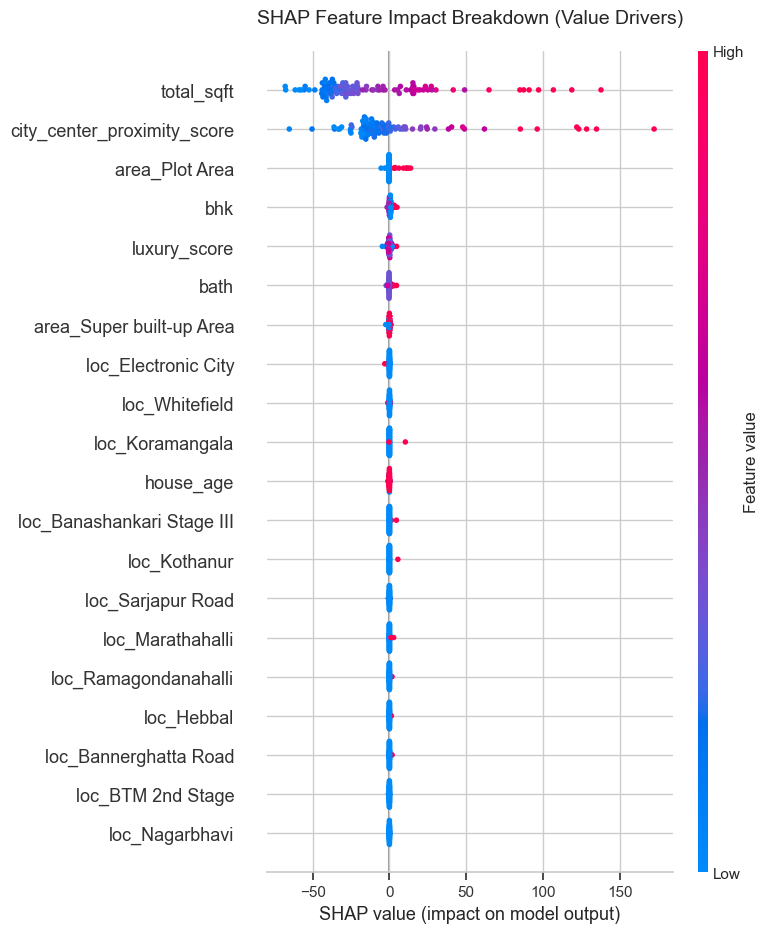

In [5]:
# Initialize Tree SHAP Explainer (optimized for Random Forests)
# We sample 100 test rows for execution speed
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test.iloc[:100])

# Plot SHAP summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:100], show=False)
plt.title('SHAP Feature Impact Breakdown (Value Drivers)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

c:\Users\varsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


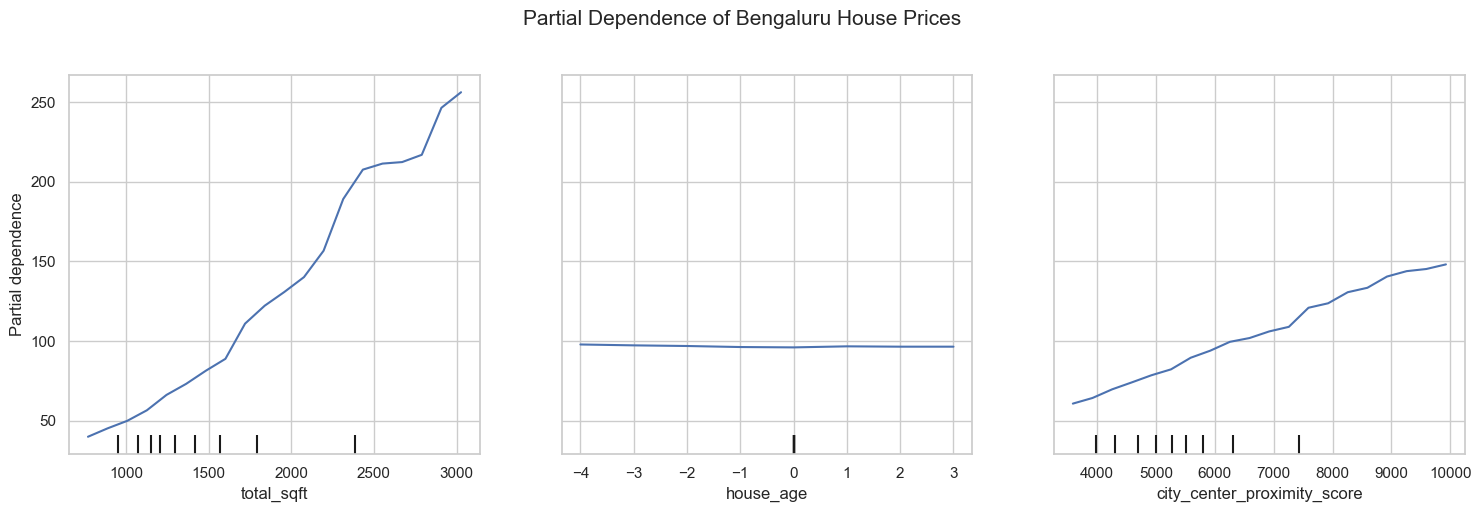

In [6]:
# Select key features to plot continuous marginal effects
features_to_plot = ['total_sqft', 'house_age', 'city_center_proximity_score']

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=X_train,
    features=features_to_plot,
    grid_resolution=20,
    ax=ax
)

plt.suptitle('Partial Dependence of Bengaluru House Prices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()